#Question-1

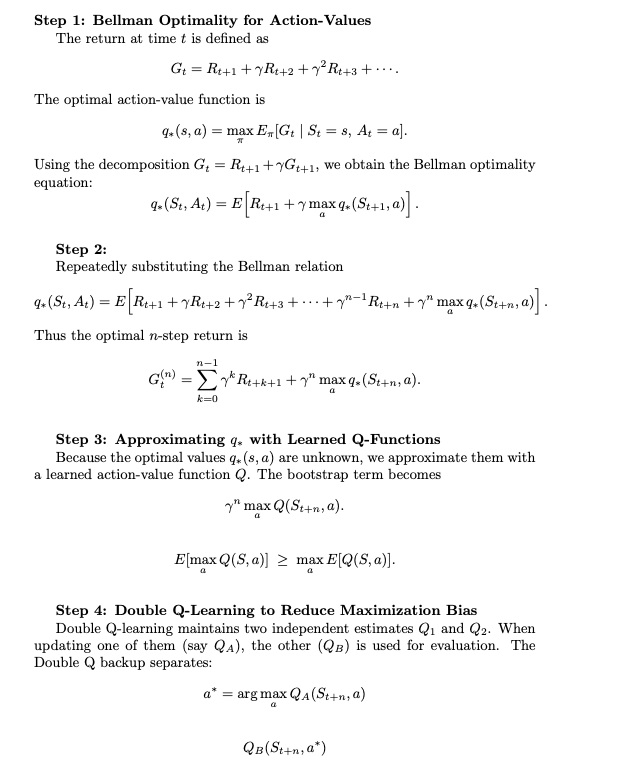

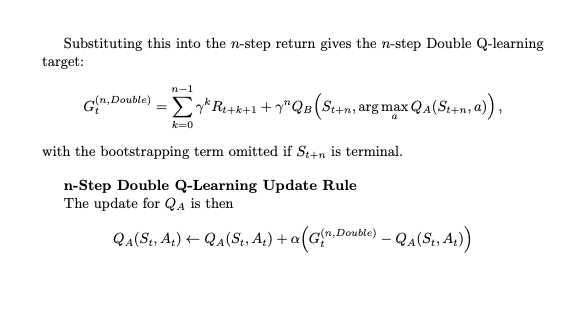

In [ ]:
#Initialising he environment from part 1
import random

class AlienPlanetEnv:
    def __init__(self):
        self.grid = [
            ["S", ".", "C", "X", ".", "."],
            [".", "X", ".", "A", ".", "."],
            [".", ".", ".", ".", "X", "."],
            [".", ".", "X", "X", "X", "."],
            [".", "A", ".", ".", ".", "."],
            [".", ".", ".", "G", ".", "C"]
        ]
        self.original_grid = [row[:] for row in self.grid]
        self.row_count = len(self.grid)
        self.column_count = len(self.grid[0])
        self.start_pos = (0, 0)
        self.agent_pos = self.start_pos
        self.actions = {0: (-1,0), 1: (1,0), 2: (0,-1), 3: (0,1)}
        self.rewards = {
            ".": -1,
            "X": -5,
            "A": -10,
            "C": 4,
            "G": 20,
            "Wall": -5
        }
        self.done = False

    def position_to_index(self, pos):
        row, column = pos
        return row * self.column_count + column


    def index_to_position(self, idx):
        return (idx // self.column_count, idx % self.column_count)

    def reset(self):
        self.grid = [row[:] for row in self.original_grid]
        self.agent_pos = self.start_pos
        self.done = False
        return self.position_to_index(self.agent_pos)

    def step(self, action):
        if self.done:
            return self.position_to_index(self.agent_pos), 0, self.done

        row, col = self.agent_pos
        row_direction, col_direction = self.actions.get(action, (0,0))
        updated_row, updated_col = row + row_direction, col + col_direction

        if updated_row < 0 or updated_row >= self.row_count or updated_col < 0 or updated_col >= self.column_count:
            reward = self.rewards["Wall"]
            return self.position_to_index(self.agent_pos), reward, self.done

        cell = self.grid[updated_row][updated_col]
        reward = self.rewards.get(cell, -1)
        self.agent_pos = (updated_row, updated_col)

        if cell == "C":
            self.grid[updated_row][updated_col] = "."

        if cell == "G":
            self.done = True

        return self.position_to_index(self.agent_pos), reward, self.done

    def render(self):
        for r in range(self.row_count):
            row_cells = ""
            for c in range(self.column_count):
                if (r,c) == self.agent_pos:
                    row_cells += "A "
                else:
                    row_cells += f"{self.grid[r][c]} "
            print(row_cells)
        print("\n")

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
#Question-2
#Here an agent is made to navigate the environment using n-step Double Q-learning.
# It keeps two Q-tables, explores using an ε-greedy strategy, collects a few steps of rewards at a time, and updates one table using information from the other
import numpy as np
import random
import matplotlib.pyplot as plt

def train_double_q(env, n=3, episodes=500, max_steps=100,
                          alpha=0.1, gamma=0.99,
                          epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                          seed=None):

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    state_count = env.row_count * env.column_count
    action_count = len(env.actions)

    Q1 = np.zeros((state_count, action_count))
    Q2 = np.zeros((state_count, action_count))

    eps = epsilon_start
    episode_rewards = []
    epsilons = []

    for ep in range(episodes):

        state = env.reset()
        if random.random() < eps:
            action = random.choice(range(action_count))
        else:
            action = int(np.argmax(Q1[state] + Q2[state]))


        state_buffer = [state]
        action_buffer = [action]
        reward_buffer = []

        total_reward = 0
        T = float('inf')
        t = 0

        while True:

            if t < T:
                next_state, reward, done = env.step(action_buffer[t])
                reward_buffer.append(reward)
                total_reward += reward

                if done:
                    T = t + 1
                else:
                    if random.random() < eps:
                        next_action = random.choice(range(action_count))
                    else:
                        next_action = int(np.argmax(Q1[next_state] + Q2[next_state]))

                    state_buffer.append(next_state)
                    action_buffer.append(next_action)

            update_time = t - n + 1

            if update_time >= 0:
                G = sum((gamma ** i) * reward_buffer[update_time + i]
                        for i in range(min(n, T - update_time)))

                if update_time + n < T:
                    future_state = state_buffer[update_time + n]

                    if random.random() < 0.5:
                        best_a = np.argmax(Q1[future_state])
                        G += (gamma ** n) * Q2[future_state, best_a]
                    else:
                        best_a = np.argmax(Q2[future_state])
                        G += (gamma ** n) * Q1[future_state, best_a]


                s_u = state_buffer[update_time]
                a_u = action_buffer[update_time]

                if random.random() < 0.5:
                    Q1[s_u, a_u] += alpha * (G - Q1[s_u, a_u])
                else:
                    Q2[s_u, a_u] += alpha * (G - Q2[s_u, a_u])

            t += 1
            if update_time == T - 1:
                break

            if t < T:
                action = action_buffer[t]

        episode_rewards.append(total_reward)
        epsilons.append(eps)
        eps = max(epsilon_min, eps * epsilon_decay)


    Q_final = (Q1 + Q2) / 2.0
    return Q_final, episode_rewards, epsilons


In [ ]:
#Qtable formatting function
def Qtable_format(Q, env):
    labels = []
    for index in range(env.row_count * env.column_count):
        pos = env.index_to_position(index)
        labels.append(f"{pos}")
    df = pd.DataFrame(Q, index=labels, columns=["Up(0)", "Down(1)", "Left(2)", "Right(3)"])
    return df

Q-table:
            Up(0)    Down(1)    Left(2)   Right(3)
(0, 0)   0.676985  11.847842   0.680508  -0.217355
(0, 1)  -7.509604  -6.691419   5.219348  -3.581860
(0, 2)  -7.910871  -4.097259  -3.998550  -7.643552
(0, 3)  -6.342192 -11.027958  -3.343871  -3.103754
(0, 4)  -5.781047  -2.641913  -6.232098  -2.614968
(0, 5)  -4.073724  -2.317459  -2.462902  -4.779021
(1, 0)   5.812231  12.977618   3.107227  -0.077982
(1, 1)  -3.178084  -2.980617   9.329951  -3.254357
(1, 2)  -3.514272  -2.815728  -6.531054 -11.617316
(1, 3)  -5.453051  -2.558798  -2.728803  -2.648737
(1, 4)  -2.373886  -5.062864  -7.523684  -2.329837
(1, 5)  -2.341144  -1.462247  -2.326328  -5.059904
(2, 0)   5.892774  14.118806   3.265725   3.699404
(2, 1)  -5.732766  -2.485012   9.406374  -2.337476
(2, 2)  -2.836613   1.206468  -2.920548  -2.949553
(2, 3)  -9.772393  -2.068863  -2.762592  -4.986033
(2, 4)  -1.669452  -2.477150  -1.888523  -1.490377
(2, 5)  -1.776273   0.462861  -4.409409  -4.767005
(3, 0)   9.067165  15.

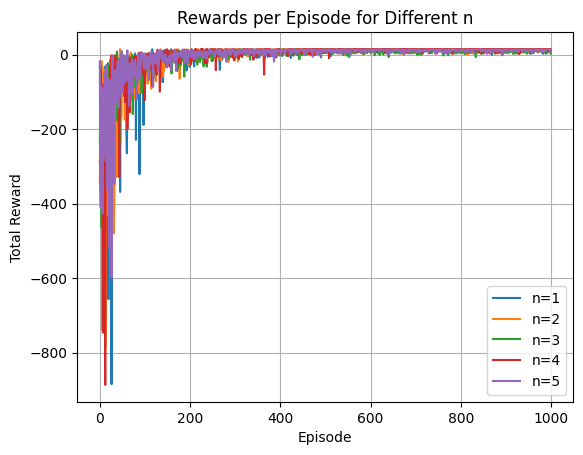

In [ ]:
env = AlienPlanetEnv()

for n in [1, 2, 3, 4, 5]:
    Qn, rewards_n, eps_n = train_double_q(env, n=n, episodes=1000)

    print("Q-table:")
    print(Qtable_format(Qn, env).to_string())

    plt.plot(rewards_n, label=f"n={n}")

plt.title("Rewards per Episode for Different n")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def evaluate_greedy(env, Q, episodes=10, max_steps=100):
    rewards_eval = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0.0

        for t in range(max_steps):
            action = int(np.argmax(Q[state]))

            next_state, reward, done = env.step(action)
            total_reward += reward

            state = next_state
            if done:
                break

        rewards_eval.append(total_reward)

    return rewards_eval


In [ ]:
greedy_scores = evaluate_greedy(env, Qn, episodes=10)
print("Greedy returns:", greedy_scores)

Greedy returns: [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0]


In [ ]:
#Performing hyperparameter tuning for the n-step Double Q-learning algorithm on the AlienPlanetEnv environment by iterating over different values of gamma,
#  epsilon decay, minimum epsilon, total training episodes, and maximum steps per episode
#Question-3

env = AlienPlanetEnv()
SEED = 50


gamma_iter = [0.90, 0.95, 0.99]
epsilon_decay_options = [0.990, 0.995, 0.999]
min_epsilon_options = [0.01, 0.05]
episode_options = [800, 1000]
max_step_options = [80, 100]

tuning_results = []


for gamma_value in gamma_iter:
    for decay_rate in epsilon_decay_options:
        for min_epsilon in min_epsilon_options:
            for total_episodes in episode_options:
                for max_steps in max_step_options:

                    learned_Q, reward_history, epsilon_history = train_double_q(env,n=3,episodes=total_episodes, max_steps=max_steps, alpha=0.1, gamma=gamma_value, epsilon_start=1.0,epsilon_min=min_epsilon,epsilon_decay=decay_rate)


                    avg_last_100 = np.mean(reward_history[-100:])

                    tuning_results.append({
                        "gamma": gamma_value,
                        "eps_decay": decay_rate,
                        "eps_min": min_epsilon,
                        "episodes": total_episodes,
                        "max_steps": max_steps,
                        "avg_score": avg_last_100,
                        "Q": learned_Q,
                        "rewards": reward_history,
                        "eps_history": epsilon_history
                    })


df_tuning = pd.DataFrame([
    {
        "gamma": res["gamma"],
        "eps_decay": res["eps_decay"],
        "eps_min": res["eps_min"],
        "episodes": res["episodes"],
        "max_steps": res["max_steps"],
        "avg_score (last100)": res["avg_score"]
    }
    for res in tuning_results
])

print("\nHyperparameter Tuning Summary:")
print(df_tuning.to_string(index=False))

best_model = max(tuning_results, key=lambda item: item["avg_score"])

print("\nBest Hyperparameters Identified:")
print(best_model)



Hyperparameter Tuning Summary:
 gamma  eps_decay  eps_min  episodes  max_steps  avg_score (last100)
  0.90      0.990     0.01       800         80                13.96
  0.90      0.990     0.01       800        100                13.79
  0.90      0.990     0.01      1000         80                13.79
  0.90      0.990     0.01      1000        100                13.60
  0.90      0.990     0.05       800         80                13.14
  0.90      0.990     0.05       800        100                13.07
  0.90      0.990     0.05      1000         80                12.83
  0.90      0.990     0.05      1000        100                12.78
  0.90      0.995     0.01       800         80                13.14
  0.90      0.995     0.01       800        100                13.11
  0.90      0.995     0.01      1000         80                13.55
  0.90      0.995     0.01      1000        100                13.88
  0.90      0.995     0.05       800         80                13.33
  

Best Hyperparameters found - {'gamma': 0.9, 'eps_decay': 0.99, 'eps_min': 0.01, 'episodes': 800, 'max_steps': 80

Effcts of Hyperparameters.
1) Discount Factor
A higher γ makes the agent look for long-term rewards but this can make the learning slow, lower γ can make the learning faster.
2) Epsilon Decay Rate
The epsilon decay rate controls how quickly the agent shifts from exploration to  start relying on what it has learned.
3) Minimum Epsilon
The minimum epsilon determines the lowest level of exploration allowed, where smaller values make the agent almost fully greedy during later training.
4) Number of Episodes
More training episodes allow the agent to explore the environment for more amount of time and converge to a better solution.
5) Maximum Steps per Episode
The maximum step limit per episode determines how much time the agent has to complete tasks, here  higher values enabling better exploration.
6) n-Step Size (n)
n decides how much future information the agent uses in each update:, where small n is stable but short-sighted, while larger n helps the agent plan further ahead

In [ ]:
#Question-5

n_values = [1, 2, 3, 4, 5]

Q_tables_by_n = {}
reward_history_by_n = {}
epsilon_history_by_n = {}
greedy_scores_by_n = {}


print("\nInitial Q-table:")
print(Qtable_format(np.zeros((env.row_count * env.column_count, 4)), env).to_string())

for n_step in n_values:
    print(f"\n Training Agent with n = {n_step}")

    final_Q, reward_history, eps_history = train_double_q(
        env,
        n=n_step,
        episodes=1000,
        max_steps=100,
        alpha=0.1,
        gamma=best_model["gamma"],
        epsilon_start=1.0,
        epsilon_min=best_model["eps_min"],
        epsilon_decay=best_model["eps_decay"],
        seed=SEED
    )

    Q_tables_by_n[n_step] = final_Q
    reward_history_by_n[n_step] = reward_history
    epsilon_history_by_n[n_step] = eps_history

    print(f"\nFinal Q-table for n = {n_step}:")
    print(Qtable_format(final_Q, env).to_string())



Initial Q-table:
        Up(0)  Down(1)  Left(2)  Right(3)
(0, 0)    0.0      0.0      0.0       0.0
(0, 1)    0.0      0.0      0.0       0.0
(0, 2)    0.0      0.0      0.0       0.0
(0, 3)    0.0      0.0      0.0       0.0
(0, 4)    0.0      0.0      0.0       0.0
(0, 5)    0.0      0.0      0.0       0.0
(1, 0)    0.0      0.0      0.0       0.0
(1, 1)    0.0      0.0      0.0       0.0
(1, 2)    0.0      0.0      0.0       0.0
(1, 3)    0.0      0.0      0.0       0.0
(1, 4)    0.0      0.0      0.0       0.0
(1, 5)    0.0      0.0      0.0       0.0
(2, 0)    0.0      0.0      0.0       0.0
(2, 1)    0.0      0.0      0.0       0.0
(2, 2)    0.0      0.0      0.0       0.0
(2, 3)    0.0      0.0      0.0       0.0
(2, 4)    0.0      0.0      0.0       0.0
(2, 5)    0.0      0.0      0.0       0.0
(3, 0)    0.0      0.0      0.0       0.0
(3, 1)    0.0      0.0      0.0       0.0
(3, 2)    0.0      0.0      0.0       0.0
(3, 3)    0.0      0.0      0.0       0.0
(3, 4)    0.0   

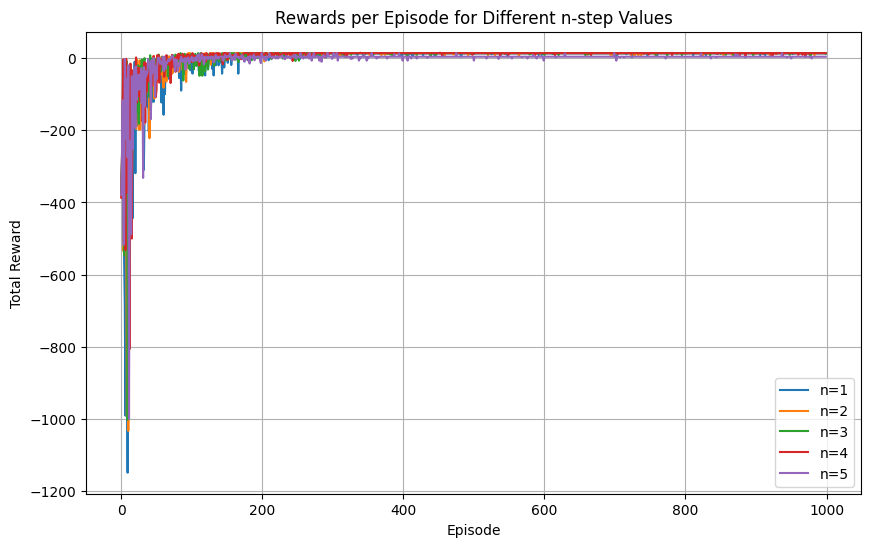

In [ ]:
plt.figure(figsize=(10,6))
for n_step in n_values:
    plt.plot(reward_history_by_n[n_step], label=f"n={n_step}")
plt.title("Rewards per Episode for Different n-step Values")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()


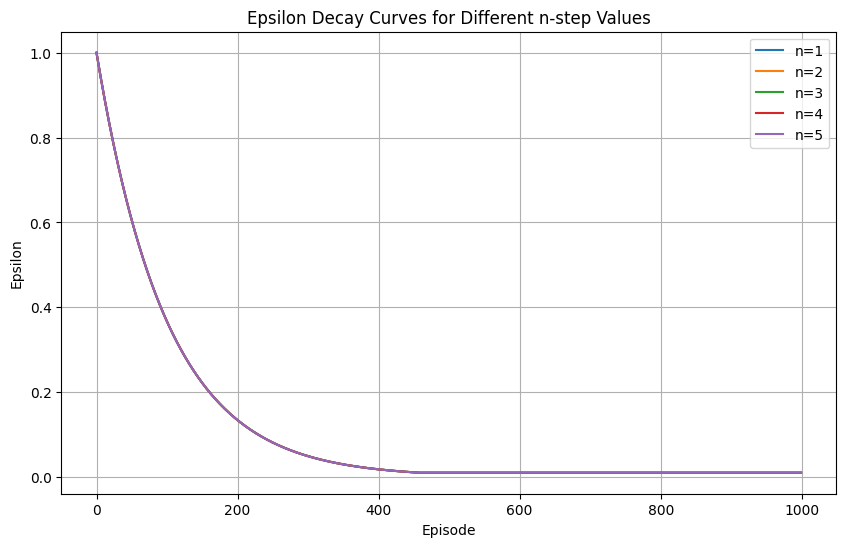

In [ ]:
plt.figure(figsize=(10,6))
for n_step in n_values:
    plt.plot(epsilon_history_by_n[n_step], label=f"n={n_step}")
plt.title("Epsilon Decay Curves for Different n-step Values")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.legend()
plt.show()


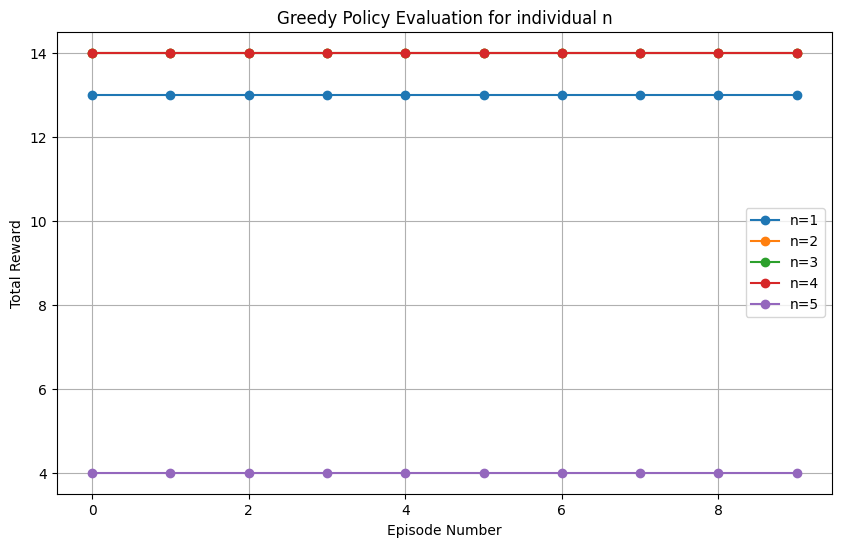


Greedy Evaluation Scores:
n=1: [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0]
n=2: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
n=3: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
n=4: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
n=5: [4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]


In [ ]:
plt.figure(figsize=(10,6))

for n_step in n_values:
    greedy_scores = evaluate_greedy(env, Q_tables_by_n[n_step], episodes=10)
    greedy_scores_by_n[n_step] = greedy_scores
    plt.plot(greedy_scores, marker='o', label=f"n={n_step}")

plt.title("Greedy Policy Evaluation for individual n")
plt.xlabel("Episode Number")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()

print("\nGreedy Evaluation Scores:")
for n_step in n_values:
    print(f"n={n_step}: {greedy_scores_by_n[n_step]}")


Graph-1 Reward Curve Analysis
The reward-per-episode graph shows that:
n = 1 -  highly noisy and unstable at the start.
n = 2, 3, 4 converge faster and show smoother learning behavior. ( but in the graoh we see that n = 3 converges faster comparitively)
n = 5 - we can infer from the graph that n=5 is unstable.
n =3 provides the optimal solution

Graph - 2 Greedy Evaluation
n=1: [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0]
n=2: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
n=3: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
n=4: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
n=5: [4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]

n = 1 gives a good and stable reward but not the maximum
n = 2, n = 3, n = 4 all achieve highest reward.
n = 5 gives the lowest reward.

Choosing n = 3 is optimal.

Q table for each n
n = 3 :
observations:

There is a clear difference between correct and incorrect actions.
The agent confidently learns the high-value actions near the goal - 20.0 in correct states.
Not much fluctuation unlike other n values.


In [ ]:
#Question-5
#Taken from part-2 SARSA training
def train_sarsa(env, episodes=500, max_steps=100, alpha=0.1, gamma=0.95, epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995, seed=None):

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    state_count = env.row_count * env.column_count
    action_list = len(env.actions)
    Q = np.zeros((state_count, action_list), dtype=float)

    eps = epsilon_start
    episode_rewards = []
    epsilons = []

    for ep in range(episodes):
        state = env.reset()

        if random.random() < eps:
            action=random.choice(range(action_list))
        else:
            action=int(np.argmax(Q[state]))

        total_reward = 0.0

        for t in range(max_steps):
            next_state, reward, done = env.step(action)
            total_reward = total_reward + reward

            if random.random() < eps:
                next_action = random.choice(range(action_list))
            else:
                next_action = int(np.argmax(Q[next_state]))
            td_target = reward + gamma * Q[next_state, next_action]
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state, action = next_state, next_action
            if done:
                break

        epsilons.append(eps)
        episode_rewards.append(total_reward)
        eps = max(epsilon_min, eps * epsilon_decay)

    return Q, episode_rewards, epsilons


In [ ]:
#Taking the best hyper parameters and running against SARSA and Double Q training loops for comparision
env = AlienPlanetEnv()
SEED = 50

gamma_value     = 0.90
epsilon_decay   = 0.99
epsilon_min     = 0.01
total_episodes  = 800
max_steps       = 80
alpha_value     = 0.1


sarsa_Q, sarsa_rewards, sarsa_epsilons = train_sarsa(
    env,
    episodes=total_episodes,
    max_steps=max_steps,
    alpha=alpha_value,
    gamma=gamma_value,
    epsilon_start=1.0,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    seed=SEED
)

n_step = 3
doubleQ_Q, doubleQ_rewards, doubleQ_epsilons = train_double_q(
    env,
    n=n_step,
    episodes=total_episodes,
    max_steps=max_steps,
    alpha=alpha_value,
    gamma=gamma_value,
    epsilon_start=1.0,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    seed=SEED
)

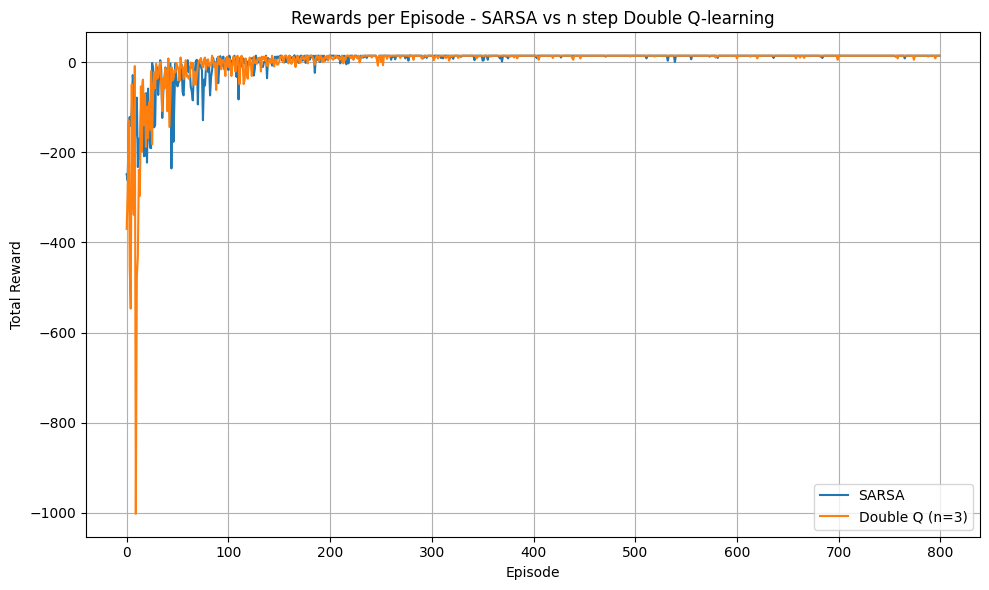

SARSA greedy returns   : [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]
Double Q (n=3) greedy returns: [14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0, 14.0]


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards,    label="SARSA")
plt.plot(doubleQ_rewards,  label=f"Double Q (n={n_step})")
plt.title("Rewards per Episode - SARSA vs n step Double Q-learning")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

sarsa_greedy   = evaluate_greedy(env, sarsa_Q,   episodes=10, max_steps=max_steps)
doubleQ_greedy = evaluate_greedy(env, doubleQ_Q, episodes=10, max_steps=max_steps)
print("SARSA greedy returns   :", sarsa_greedy)
print(f"Double Q (n={n_step}) greedy returns:", doubleQ_greedy)

Comparision between SARSA and  Double Q-learning

Double Q-learning is faster than SARSA in learning.
Double Q-learning  starts off with a lower reward than SARSA but converges quickly.
n-step Double Q  stabilizes earlier and converges toward higher rewards.
SARSA is  sensitive to epsilon than Double Q-learning because its updates depend on behavior policy.